# 🍷 Wine Quality Classification
### Using Physicochemical Properties | Dataset: WineQT

## Block 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('✅ All Libraries Imported Successfully!')

✅ All Libraries Imported Successfully!


## Block 2: Load Dataset

In [2]:
# Load WineQT dataset
df = pd.read_csv('WineQT.csv')
print('Dataset Shape:', df.shape)
print('\nFirst 5 Rows:')
df.head()

Dataset Shape: (1143, 13)

First 5 Rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Block 3: Dataset Info

In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Dataset Columns ===')
print(df.columns.tolist())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

=== Dataset Columns ===
['fixed acidity', 'volatile a

## Block 4: Statistical Summary

In [4]:
print('=== Statistical Description ===')
df.describe()

=== Statistical Description ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


## Block 5: Check Missing Values & Duplicates

In [5]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Duplicate Rows ===')
print('Total Duplicates:', df.duplicated().sum())
df = df.drop_duplicates()
print('After Removing Duplicates Shape:', df.shape)

=== Missing Values ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

=== Duplicate Rows ===
Total Duplicates: 0
After Removing Duplicates Shape: (1143, 13)


## Block 6: Target Variable - Quality Distribution
### 📊 Graph 1: Bar Chart of Wine Quality Distribution

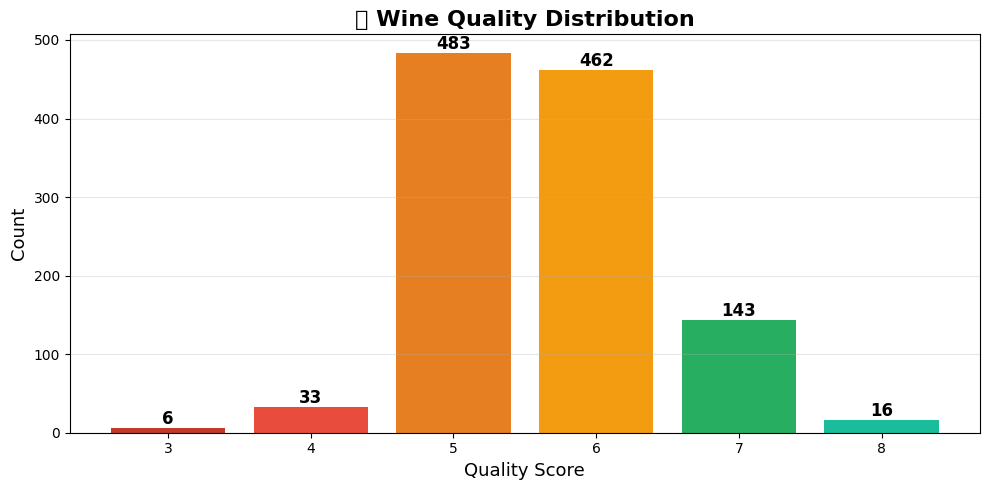

Quality Value Counts:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(10, 5))
quality_counts = df['quality'].value_counts().sort_index()
bars = plt.bar(quality_counts.index, quality_counts.values, color=['#c0392b','#e74c3c','#e67e22','#f39c12','#27ae60','#1abc9c'])
for bar, count in zip(bars, quality_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', fontsize=12, fontweight='bold')
plt.title('🍷 Wine Quality Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Quality Score', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Quality Value Counts:')
print(df['quality'].value_counts().sort_index())

## Block 7: Create Quality Labels (Good / Bad)

In [7]:
# Classify: quality >= 7 → Good, else → Bad
df['quality_label'] = df['quality'].apply(lambda x: 'Good' if x >= 7 else 'Bad')

print('Quality Label Distribution:')
print(df['quality_label'].value_counts())
print(f"\nGood Wine: {(df['quality_label']=='Good').sum()} samples")
print(f"Bad Wine:  {(df['quality_label']=='Bad').sum()} samples")

Quality Label Distribution:
quality_label
Bad     984
Good    159
Name: count, dtype: int64

Good Wine: 159 samples
Bad Wine:  984 samples


## Block 8: Correlation Heatmap
### 📊 Graph 2: Feature Correlation Heatmap

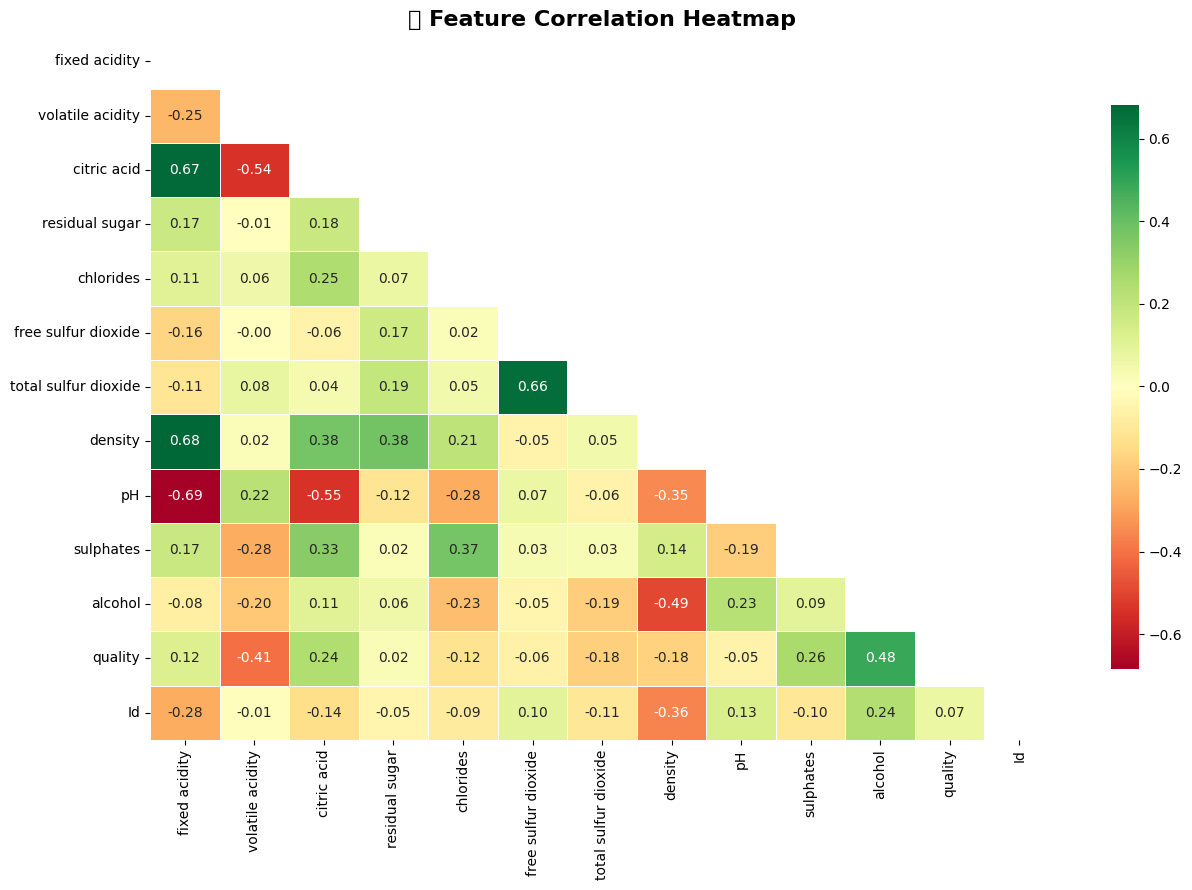

In [8]:
plt.figure(figsize=(13, 9))
corr = df.drop(columns=['quality_label']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask, linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('🔥 Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Block 9: Feature Distribution by Quality
### 📊 Graph 3: Boxplot - Key Features vs Quality

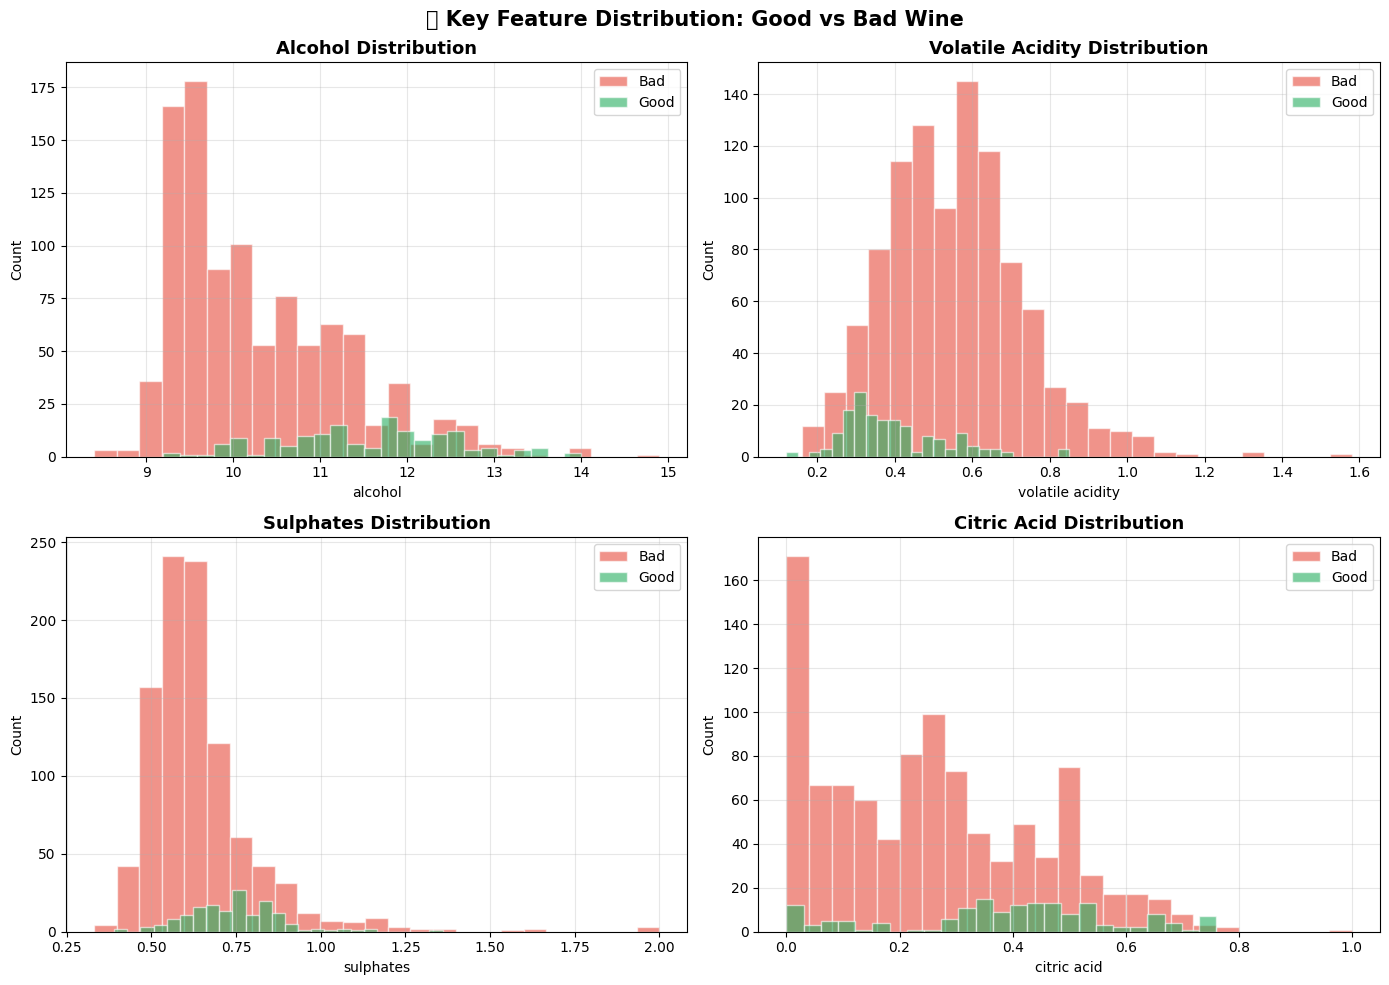

In [9]:
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = {'Bad': '#e74c3c', 'Good': '#27ae60'}
for i, feature in enumerate(key_features):
    for label, color in colors.items():
        subset = df[df['quality_label'] == label][feature]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'{feature.title()} Distribution', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('📦 Key Feature Distribution: Good vs Bad Wine', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Block 10: Feature Engineering & Preprocessing

In [10]:
# Drop original quality col, drop 'Id' if exists
drop_cols = ['quality', 'quality_label']
if 'Id' in df.columns:
    drop_cols.append('Id')

X = df.drop(columns=drop_cols)
y = df['quality_label']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Bad=0, Good=1

print('Features Shape:', X.shape)
print('Target Shape:', y_encoded.shape)
print('Classes:', le.classes_)
print('\nFeatures used:')
print(X.columns.tolist())

Features Shape: (1143, 11)
Target Shape: (1143,)
Classes: ['Bad' 'Good']

Features used:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## Block 11: Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print('Training Set Size:', X_train.shape)
print('Testing Set Size :', X_test.shape)
print(f'Train - Bad: {(y_train==0).sum()}, Good: {(y_train==1).sum()}')
print(f'Test  - Bad: {(y_test==0).sum()},  Good: {(y_test==1).sum()}')

Training Set Size: (914, 11)
Testing Set Size : (229, 11)
Train - Bad: 787, Good: 127
Test  - Bad: 197,  Good: 32


## Block 12: Feature Scaling

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Features Scaled using StandardScaler')
print('Mean of scaled training data (should be ~0):', X_train_scaled.mean().round(4))
print('Std  of scaled training data (should be ~1):', X_train_scaled.std().round(4))

✅ Features Scaled using StandardScaler
Mean of scaled training data (should be ~0): 0.0
Std  of scaled training data (should be ~1): 1.0


## Block 13: Model 1 - Logistic Regression

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
print('=== Logistic Regression ===')
print(f'Accuracy: {acc_lr*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

=== Logistic Regression ===
Accuracy: 86.46%

Classification Report:
              precision    recall  f1-score   support

         Bad       0.90      0.95      0.92       197
        Good       0.52      0.34      0.42        32

    accuracy                           0.86       229
   macro avg       0.71      0.65      0.67       229
weighted avg       0.85      0.86      0.85       229



## Block 14: Model 2 - Support Vector Machine (SVM)

In [14]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

acc_svm = accuracy_score(y_test, y_pred_svm)
print('=== Support Vector Machine ===')
print(f'Accuracy: {acc_svm*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

=== Support Vector Machine ===
Accuracy: 89.96%

Classification Report:
              precision    recall  f1-score   support

         Bad       0.91      0.98      0.94       197
        Good       0.76      0.41      0.53        32

    accuracy                           0.90       229
   macro avg       0.84      0.69      0.74       229
weighted avg       0.89      0.90      0.89       229



## Block 15: Model 3 - K-Nearest Neighbors (KNN)

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
print('=== K-Nearest Neighbors ===')
print(f'Accuracy: {acc_knn*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

=== K-Nearest Neighbors ===
Accuracy: 86.46%

Classification Report:
              precision    recall  f1-score   support

         Bad       0.91      0.93      0.92       197
        Good       0.52      0.44      0.47        32

    accuracy                           0.86       229
   macro avg       0.71      0.69      0.70       229
weighted avg       0.86      0.86      0.86       229



## Block 16: Model 4 - Naive Bayes

In [16]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred_nb)
print('=== Naive Bayes ===')
print(f'Accuracy: {acc_nb*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

=== Naive Bayes ===
Accuracy: 84.28%

Classification Report:
              precision    recall  f1-score   support

         Bad       0.93      0.88      0.91       197
        Good       0.45      0.59      0.51        32

    accuracy                           0.84       229
   macro avg       0.69      0.74      0.71       229
weighted avg       0.86      0.84      0.85       229



## Block 17: Model Comparison
### 📊 Graph 4: Accuracy Comparison Bar Chart + Confusion Matrices

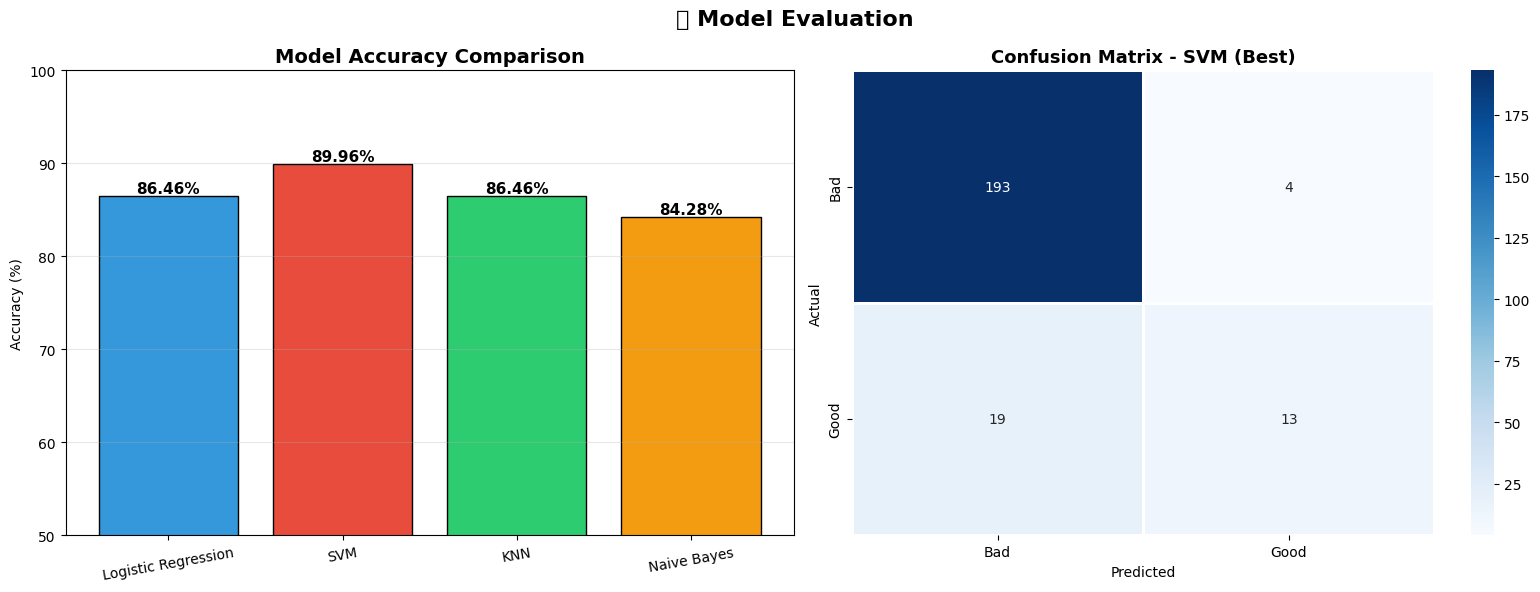


🏆 Best Model: SVM with 89.96% accuracy


In [17]:
models_name = ['Logistic Regression', 'SVM', 'KNN', 'Naive Bayes']
accuracies  = [acc_lr, acc_svm, acc_knn, acc_nb]
preds_list  = [y_pred_lr, y_pred_svm, y_pred_knn, y_pred_nb]
palette     = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar Chart ---
bars = axes[0].bar(models_name, [a*100 for a in accuracies], color=palette, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc*100:.2f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(50, 100)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=10)

# --- Best Model Confusion Matrix ---
best_idx = accuracies.index(max(accuracies))
best_pred = preds_list[best_idx]
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=1)
axes[1].set_title(f'Confusion Matrix - {models_name[best_idx]} (Best)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('🏆 Model Evaluation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n🏆 Best Model: {models_name[best_idx]} with {max(accuracies)*100:.2f}% accuracy')

## Block 18: Final Summary & Conclusion

In [18]:
results_df = pd.DataFrame({
    'Model': models_name,
    'Accuracy (%)': [round(a*100, 2) for a in accuracies]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print('='*40)
print('   🍷 WINE QUALITY CLASSIFICATION')
print('        FINAL RESULTS SUMMARY')
print('='*40)
print(results_df.to_string(index=False))
print('='*40)
print(f'\n✅ Best Model  : {results_df.iloc[0]["Model"]}')
print(f'✅ Best Accuracy: {results_df.iloc[0]["Accuracy (%)"]:.2f}%')
print('\n📌 Conclusion:')
print('   Wine quality can be classified using physicochemical properties.')
print('   Alcohol, volatile acidity & sulphates are key predictors.')
print('   SVM & Logistic Regression perform best on this dataset.')

   🍷 WINE QUALITY CLASSIFICATION
        FINAL RESULTS SUMMARY
              Model  Accuracy (%)
                SVM         89.96
Logistic Regression         86.46
                KNN         86.46
        Naive Bayes         84.28

✅ Best Model  : SVM
✅ Best Accuracy: 89.96%

📌 Conclusion:
   Wine quality can be classified using physicochemical properties.
   Alcohol, volatile acidity & sulphates are key predictors.
   SVM & Logistic Regression perform best on this dataset.
